# Separación Temporal de Datos — Pre / Intra / Post Cirugía

### TFG — Ingeniería en Ciencia de Datos · Iker Arias · 2026

Este notebook ejecuta el pipeline completo de segmentación temporal de los datos clínicos brutos:

| Paso | Descripción | Módulo |
|------|-------------|--------|
| **1** | Carga del CSV de referencia quirúrgica | `vision_data` |
| **2** | Selección del primer episodio principal por paciente | `vision_data` |
| **3** | Normalización de nombres de columnas (`id_paciente`, `fecha_evento`) | `preprocces` |
| **4** | Segmentación en **pre / intra / post** cirugía | `divide` |
| **5** | Análisis y visualización de la distribución por segmento | `division_ev` |

### Estructura de carpetas resultante
```
data/
├── data_raw/           ← CSVs originales (sin tocar)
├── data_normalized/    ← CSVs con columnas estandarizadas
└── data_divided/
    ├── pre/            ← Eventos ANTES de la cirugía
    ├── intra/          ← Eventos DURANTE la cirugía
    ├── post/           ← Eventos DESPUÉS de la cirugía
    ├── static/         ← Archivos sin dimensión temporal
    └── sin_referencia/ ← Pacientes sin cirugía de referencia
```

---
## 0. Configuración de rutas e imports

In [1]:
import os, sys
from pathlib import Path

# Anclar CWD al root del proyecto (TFG/) independientemente de donde se abra el notebook
_here = Path().resolve()
if _here.name == 'notebooks':
    os.chdir(_here.parent)
PROJECT_ROOT = Path().resolve()
print(f'Project root: {PROJECT_ROOT}')

# Añadir src/ al sys.path para que funcionen los imports
src_path = str(PROJECT_ROOT / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
print(f'src/ en sys.path: {src_path}')

# Rutas de datos
RAW_PATH        = PROJECT_ROOT / 'data' / 'data_raw'
NORMALIZED_PATH = PROJECT_ROOT / 'data' / 'data_normalized'
DIVIDED_PATH    = PROJECT_ROOT / 'data' / 'data_divided'

print(f'\nRutas:')
print(f'  RAW:        {RAW_PATH}')
print(f'  NORMALIZED: {NORMALIZED_PATH}')
print(f'  DIVIDED:    {DIVIDED_PATH}')
print(f'\nCSVs en data_raw: {len(list(RAW_PATH.glob("*.csv")))}')

Project root: /Users/ikerarias/Desktop/TFG
src/ en sys.path: /Users/ikerarias/Desktop/TFG/src

Rutas:
  RAW:        /Users/ikerarias/Desktop/TFG/data/data_raw
  NORMALIZED: /Users/ikerarias/Desktop/TFG/data/data_normalized
  DIVIDED:    /Users/ikerarias/Desktop/TFG/data/data_divided

CSVs en data_raw: 46


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from utils import vision_data as vd
from utils import division_ev as dvev
from preproccesing import preprocces as pr
from preproccesing.divide import segmentar_y_guardar

print('✓ Imports correctos')

✓ Imports correctos


---
## 1. Cargar CSV de referencia quirúrgica

El archivo `009_INTERVENCIONES_QUIRURGICAS_INTERVENCION.csv` contiene una fila por intervención
con las columnas `Hora (inicio)` y `Hora Intervención (fin)` que definen la ventana temporal de la cirugía.
Este archivo sirve como **referencia temporal** para todo el pipeline.

In [3]:
csv_ref = RAW_PATH / '009_INTERVENCIONES_QUIRURGICAS_INTERVENCION.csv'

df_ref = vd.cargar_csv(csv_ref)
print(f'Shape: {df_ref.shape}')
print(f'Columnas: {list(df_ref.columns)}')
df_ref.head()

Shape: (15087, 17)
Columnas: ['cod Solicitud', 'Id Paciente', 'Episodio INTER', 'Episodio (único) INTER', 'Hora (inicio)', 'Hora Intervención (fin)', 'Principal o secundaria', 'Tipo anestesia', 'Riesgo anestésico (ASA)', 'Prioridad ingreso', 'Proceso quirúrgico', 'Motivo ingreso', 'Tipo de procedimiento quirúrgico', 'Infección intraoperatoria', 'Tipo de intervención', 'Duración Intervención', 'Prioridad de la intervención']


,cod Solicitud,Id Paciente,Episodio INTER,Episodio (único) INTER,Hora (inicio),Hora Intervención (fin),Principal o secundaria,Tipo anestesia,Riesgo anestésico (ASA),Prioridad ingreso,Proceso quirúrgico,Motivo ingreso,Tipo de procedimiento quirúrgico,Infección intraoperatoria,Tipo de intervención,Duración Intervención,Prioridad de la intervención
0,1,46243,1203919,62656782,2019-01-15 08:40:00,2019-01-15 11:00:00,PRINCIPAL,INTRADURAL,III,PROGRAMADO,PROTESIS CADERA,ENFERMEDAD,CIRUGIA MAYOR,NO,CIRUGIA MAYOR,140,Ordinaria
1,2,36960,1559727,62604460,2019-01-09 17:15:00,2019-01-09 18:00:00,PRINCIPAL,LOCAL + SEDACION,I,PROGRAMADO,MENISCECTOMIA,ENFERMEDAD,CIRUGIA MAYOR,NO,CIRUGIA MAYOR,45,Ordinaria
2,3,35808,1211351,63749342,2019-05-09 12:00:00,2019-05-09 13:15:00,PRINCIPAL,GENERAL,I,PROGRAMADO,E.M.O.,ENFERMEDAD,CIRUGIA MENOR,NO,CIRUGIA MAYOR,75,Ordinaria
3,4,22369,1204842,62787050,2019-01-28 12:25:00,2019-01-28 17:15:00,PRINCIPAL,INTRADURAL,III,PROGRAMADO,ARTRODESIS / ARTROPLASTIA,ENFERMEDAD,CIRUGIA MAYOR,NO,CIRUGIA MAYOR,290,Ordinaria
4,4,22369,1204842,62787050,2019-01-28 12:25:00,2019-01-28 17:15:00,SECUNDARIA,INTRADURAL,III,PROGRAMADO,OTROS,ENFERMEDAD,CIRUGIA MENOR,NO,CIRUGIA MAYOR,290,Ordinaria


In [4]:
# Convertir columnas de hora a datetime
df_ref = vd.convertir_a_datetime(
    df_ref,
    ['Hora (inicio)', 'Hora Intervención (fin)']
)

print('Tipos de columnas de tiempo:')
print(df_ref[['Hora (inicio)', 'Hora Intervención (fin)']].dtypes)
print(f'\nFechas nulas en Hora (inicio): {df_ref["Hora (inicio)"].isna().sum()}')
print(f'Fechas nulas en Hora Intervención (fin): {df_ref["Hora Intervención (fin)"].isna().sum()}')

Tipos de columnas de tiempo:
Hora (inicio)              datetime64[us]
Hora Intervención (fin)    datetime64[us]
dtype: object

Fechas nulas en Hora (inicio): 0
Fechas nulas en Hora Intervención (fin): 0


/Users/ikerarias/Desktop/TFG/src/utils/vision_data.py:34: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
/Users/ikerarias/Desktop/TFG/src/utils/vision_data.py:34: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)


---
## 2. Primer episodio principal por paciente

Cada paciente puede tener múltiples intervenciones. Seleccionamos **una sola cirugía de referencia**
por paciente con esta lógica:
1. Se filtra solo intervenciones marcadas como `PRINCIPAL`
2. Se prioriza `CIRUGIA MAYOR` sobre cualquier otro tipo
3. Si hay varias, se toma la **primera cronológicamente**

In [5]:
df_primero = vd.primer_episodio_principal(df_ref)

print(f'Pacientes únicos en referencia original: {df_ref["Id Paciente"].nunique()}')
print(f'Pacientes con cirugía de referencia seleccionada: {len(df_primero)}')
print(f'\nDistribución por tipo de procedimiento:')
if 'Tipo de procedimiento quirúrgico' in df_primero.columns:
    print(df_primero['Tipo de procedimiento quirúrgico'].value_counts())
df_primero.head()

Pacientes únicos en referencia original: 12288
Pacientes con cirugía de referencia seleccionada: 12288

Distribución por tipo de procedimiento:
Tipo de procedimiento quirúrgico
CIRUGIA MAYOR    9353
CIRUGIA MENOR    1602
NO QUIRURGICO    1333
Name: count, dtype: int64


,Id Paciente,cod Solicitud,Episodio INTER,Episodio (único) INTER,Hora (inicio),Hora Intervención (fin),Principal o secundaria,Tipo anestesia,Riesgo anestésico (ASA),Prioridad ingreso,Proceso quirúrgico,Motivo ingreso,Tipo de procedimiento quirúrgico,Infección intraoperatoria,Tipo de intervención,Duración Intervención,Prioridad de la intervención
0,4,4916,1211923,63832140,2019-05-17 13:05:00,2019-05-17 14:35:00,PRINCIPAL,INTRADURAL,IV,PROGRAMADO,RTU VEJIGA,ENFERMEDAD,CIRUGIA MAYOR,NO,CIRUGIA MAYOR,90,Ordinaria
1,8,1308,1206475,63022069,2019-02-20 08:30:00,2019-02-20 10:10:00,PRINCIPAL,INTRADURAL,III,PROGRAMADO,HERNIAS,ENFERMEDAD,CIRUGIA MAYOR,NO,CIRUGIA MAYOR,100,Ordinaria
2,12,10720,1222480,65455395,2019-11-14 08:45:00,2019-11-14 10:05:00,PRINCIPAL,GENERAL,III,PROGRAMADO,HERNIAS,ENFERMEDAD,CIRUGIA MAYOR,NO,CIRUGIA MAYOR,80,Ordinaria
3,15,6665,1563315,63985528,2019-06-03 11:40:00,2019-06-03 12:05:00,PRINCIPAL,LOCAL,I,PROGRAMADO,CATARATAS,ENFERMEDAD,CIRUGIA MAYOR,NO,CIRUGIA MAYOR,25,Ordinaria
4,20,9706,1215638,64383506,2019-07-16 13:20:00,2019-07-16 14:55:00,PRINCIPAL,INTRADURAL,III,URGENTE,OSTEOSINTESIS/INJERT OSEO,ACC.CASUAL,CIRUGIA MAYOR,NO,CIRUGIA MAYOR,95,Ordinaria


---
## 3. Normalización de columnas

Los CSVs brutos usan nombres de columna inconsistentes (`Id Paciente`, `Id_Paciente`,
`Identificador de Paciente`, etc.). Este paso estandariza todos a `id_paciente` y `fecha_evento`
para que el paso de segmentación funcione correctamente.

**Salida:** `data/data_normalized/` — mismos archivos con columnas renombradas.

In [6]:
print('Normalizando columnas de todos los CSVs...')
print('=' * 60)
pr.normalizar_CSVs(RAW_PATH, NORMALIZED_PATH)
print(f'\n✓ CSVs normalizados guardados en: {NORMALIZED_PATH}')
print(f'  Archivos generados: {len(list(NORMALIZED_PATH.glob("*.csv")))}')

Normalizando columnas de todos los CSVs...
Archivos encontrados: 46

Procesando 000_POBLACION_DIANA.csv…
    → estático, copiado sin cambios
Procesando 001_INTERVENCIONES_QUIRURGICAS.csv…
    → estático, copiado sin cambios
Procesando 002_SOCIODEMOGRAFICOS_ALCOHOL.csv…
    ✔ 'Id_Paciente'  →  'id_paciente'
    ✔ 'Dia (Fecha)'  →  'fecha_evento'
Procesando 003_SOCIODEMOGRAFICOS_TABACO.csv…
    ✔ 'Id_Paciente'  →  'id_paciente'
    ✔ 'Dia (Fecha)'  →  'fecha_evento'
Procesando 004_DIAGNOSTICO_PRINCIPAL_CIE10.csv…
    → estático, copiado sin cambios
Procesando 005_DIAGNOSTICO_PRINCIPAL_CIE9.csv…
    → estático, copiado sin cambios
Procesando 006_COMORBILIDADES_CHARLSON.csv…
    → estático, copiado sin cambios
Procesando 006_COMORBILIDADES_CHARLSON_NUEVO.csv…
    → estático, copiado sin cambios
Procesando 007_INTERVENCIONES_QUIRURGICAS_SOLICITUD.csv…
    ✔ 'Id_Paciente'  →  'id_paciente'
    ✔ 'Episodio (unico) SOLIC'  →  'id_episodio'
    ✔ 'Fecha (solicitud)'  →  'fecha_evento'
Procesand

---
## 4. Segmentación temporal: Pre / Intra / Post

Para cada archivo normalizado, se hace un **join con la tabla de referencia** usando `id_paciente`
y se clasifica cada evento según su `fecha_evento` respecto a la ventana quirúrgica:

| Segmento | Condición |
|----------|-----------|
| **pre** | `fecha_evento < Hora (inicio)` |
| **intra** | `Hora (inicio) ≤ fecha_evento ≤ Hora Intervención (fin)` |
| **post** | `fecha_evento > Hora Intervención (fin)` |
| **static** | Archivos sin dimensión temporal (comorbilidades, diagnósticos...) |
| **sin_referencia** | Pacientes sin cirugía de referencia en el dataset |

**Salida:** `data/data_divided/{pre,intra,post,static,sin_referencia}/`

In [7]:
print('Segmentando datos en Pre / Intra / Post cirugía...')
print('=' * 60)
segmentar_y_guardar(NORMALIZED_PATH, df_primero, DIVIDED_PATH)
print(f'\n✓ Segmentación completada en: {DIVIDED_PATH}')

Segmentando datos en Pre / Intra / Post cirugía...
  ⚠ 2 cirugía(s) con Hora inicio > Hora fin → intercambiando automáticamente
Archivos encontrados: 46

Procesando 000_POBLACION_DIANA.csv…
    → estático guardado en /static
Procesando 001_INTERVENCIONES_QUIRURGICAS.csv…
    → estático guardado en /static
Procesando 002_SOCIODEMOGRAFICOS_ALCOHOL.csv…
    → sin_referencia: 6146 filas guardadas en /sin_referencia
    ✔ pre: 52146 filas
    ✔ post: 240 filas
Procesando 003_SOCIODEMOGRAFICOS_TABACO.csv…
    → sin_referencia: 12185 filas guardadas en /sin_referencia
    ✔ pre: 90653 filas
    ✔ post: 7280 filas
Procesando 004_DIAGNOSTICO_PRINCIPAL_CIE10.csv…
    → estático guardado en /static
Procesando 005_DIAGNOSTICO_PRINCIPAL_CIE9.csv…
    → estático guardado en /static
Procesando 006_COMORBILIDADES_CHARLSON.csv…
    → estático guardado en /static
Procesando 006_COMORBILIDADES_CHARLSON_NUEVO.csv…
    → estático guardado en /static
Procesando 007_INTERVENCIONES_QUIRURGICAS_SOLICITUD.csv…


---
## 5. Análisis de la segmentación

Revisamos la distribución de filas y pacientes únicos por cada segmento para validar
que la separación es coherente.

RESUMEN DE SEGMENTACIÓN

📊 FILAS POR SEGMENTO:
segmento                                               intra    post     pre  sin_referencia   TOTAL
archivo                                                                                             
002_SOCIODEMOGRAFICOS_ALCOHOL.csv                          0     240   52146            6146   58532
003_SOCIODEMOGRAFICOS_TABACO.csv                           0    7280   90653           12185  110118
007_INTERVENCIONES_QUIRURGICAS_SOLICITUD.csv               5       0   12101               0   12106
008_INTERVENCIONES_QUIRURGICAS_CONTACTO_ANESTESIA.csv      0       0     177               0     177
010_LABORATORIO.csv                                       24    1993     390             251    2658
010_LABORATORIO_2019_1.csv                                 0    2334    1731             534    4599
010_LABORATORIO_2019_2.csv                                 1     916     881             200    1998
010_LABORATORIO_2019_3.csv                  

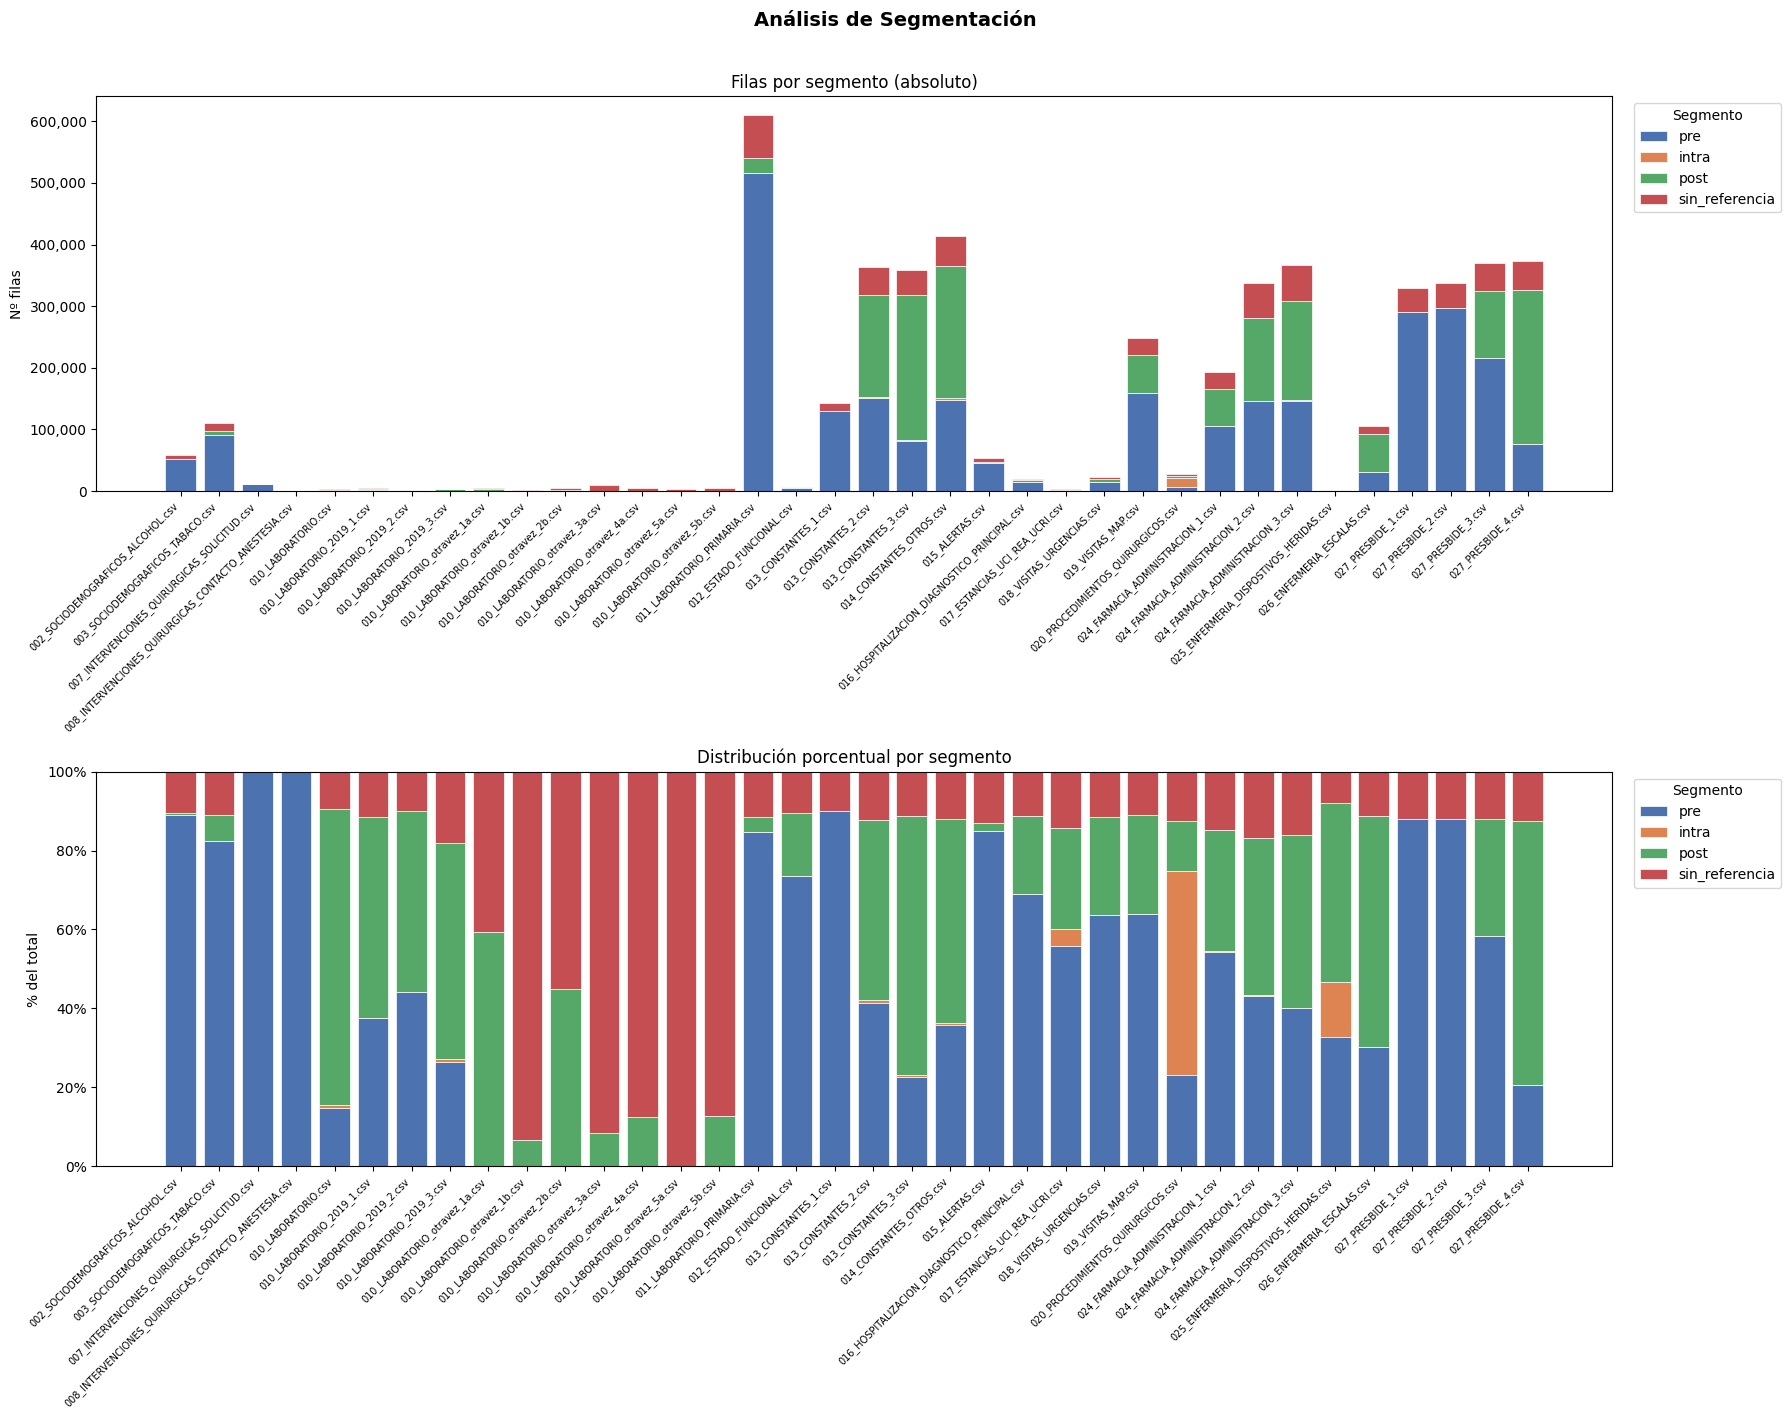


✅ Gráfico guardado en /Users/ikerarias/Desktop/TFG/data/data_divided/analisis_segmentacion.png


In [8]:
df_analisis = dvev.analizar_segmentacion(DIVIDED_PATH)

---
## 6. Resumen de archivos generados

In [9]:
print('=' * 70)
print('RESUMEN DE ARCHIVOS GENERADOS')
print('=' * 70)
for subfolder in ['pre', 'intra', 'post', 'static', 'sin_referencia']:
    folder = DIVIDED_PATH / subfolder
    if folder.exists():
        csvs = list(folder.glob('*.csv'))
        total_rows = 0
        for csv in csvs:
            try:
                total_rows += len(pd.read_csv(csv, engine='python', on_bad_lines='skip'))
            except Exception:
                pass
        print(f'  {subfolder:20s}: {len(csvs):3d} archivos  |  {total_rows:>10,} filas totales')
    else:
        print(f'  {subfolder:20s}: (vacío)')
print('=' * 70)
print('\n✅ Pipeline completado. Datos listos para modelado.')

RESUMEN DE ARCHIVOS GENERADOS
  pre                 :  29 archivos  |   2,739,544 filas totales
  intra               :  19 archivos  |      23,590 filas totales
  post                :  31 archivos  |   1,516,458 filas totales
  static              :   9 archivos  |     213,350 filas totales
  sin_referencia      :  34 archivos  |     636,090 filas totales

✅ Pipeline completado. Datos listos para modelado.
